# Recommended trajectory workflow — Slingshot

This is the day-one walkthrough for `ov.single.TrajInfer`. We use Slingshot
as the backend because it scored best in our [no-leakage dynbenchmark
re-run](https://github.com/omicverse/py-dynbenchmark) (overall 0.49,
matching R Slingshot byte-for-byte on cell-position correlation) and it
handles **branching topologies** out of the box.

If you want a different backend, swap one line:
`Traj.inference(method='palantir')` / `'diffusion_map'` / `'sctour'` /
`'stavia'` / `'scorpius'` / `'tscan'` / `'destiny'` / `'urd'` /
`'monocle3'` / `'cytotrace'`. The zoo below has one tutorial per method.

Using endocrine pancreas development as an example, this tutorial demonstrates Slingshot lineage fitting, pseudotime visualization, and lineage-aware dynamic trend summaries.

## Method background

See the [Bioconductor Slingshot vignette](https://bioconductor.org/packages/release/bioc/vignettes/slingshot/inst/doc/vignette.html) and the original [BMC Genomics paper](https://bmcgenomics.biomedcentral.com/articles/10.1186/s12864-018-4772-0).

In [1]:
import scanpy as sc
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import omicverse as ov
ov.plot_set(font_path='Arial')

%load_ext autoreload
%autoreload 2

🔬 Starting plot initialization...
Using already downloaded Arial font from: /var/folders/rv/3jnfbs0d6r7d0c5bfj7ft5k00000gn/T/omicverse_arial.ttf


Matplotlib is building the font cache; this may take a moment.


Registered as: Arial
🧬 Detecting GPU devices…
✅ Apple Silicon MPS detected
    • [MPS] Apple Silicon GPU - Metal Performance Shaders available

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.1rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



In [2]:
adata = ov.datasets.pancreatic_endocrinogenesis()

⚠️ File ./data/endocrinogenesis_day15.h5ad already exists
 Loading data from ./data/endocrinogenesis_day15.h5ad
✅ Successfully loaded: 3696 cells × 27998 genes


In [3]:
adata = ov.pp.preprocess(adata, mode='shiftlog|pearson', n_HVGs=3000)
adata.raw = adata
adata = adata[:, adata.var.highly_variable_features]
ov.pp.scale(adata)
ov.pp.pca(adata, layer='scaled', n_pcs=50)

🔍 [2026-05-22 18:42:49] Running preprocessing in 'cpu' mode...
Begin robust gene identification
    After filtration, 17750/27998 genes are kept.
    Among 17750 genes, 16426 genes are robust.
✅ Robust gene identification completed successfully.
Begin size normalization: shiftlog and HVGs selection pearson

🔍 Count Normalization:
   Target sum: 500000.0
   Exclude highly expressed: True
   Max fraction threshold: 0.2
   ⚠️ Excluding 1 highly-expressed genes from normalization computation
   Excluded genes: ['Ghrl']

✅ Count Normalization Completed Successfully!
   ✓ Processed: 3,696 cells × 16,426 genes
   ✓ Runtime: 0.11s

🔍 Highly Variable Genes Selection (Experimental):
   Method: pearson_residuals
   Target genes: 3,000
   Theta (overdispersion): 100


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.



✅ Experimental HVG Selection Completed Successfully!
   ✓ Selected: 3,000 highly variable genes out of 16,426 total (18.3%)
   ✓ Results added to AnnData object:
     • 'highly_variable': Boolean vector (adata.var)
     • 'highly_variable_rank': Float vector (adata.var)
     • 'highly_variable_nbatches': Int vector (adata.var)
     • 'highly_variable_intersection': Boolean vector (adata.var)
     • 'means': Float vector (adata.var)
     • 'variances': Float vector (adata.var)
     • 'residual_variances': Float vector (adata.var)
    Time to analyze data in cpu: 0.94 seconds.
✅ Preprocessing completed successfully.
    Added:
        'highly_variable_features', boolean vector (adata.var)
        'means', float vector (adata.var)
        'variances', float vector (adata.var)
        'residual_variances', float vector (adata.var)
        'counts', raw counts layer (adata.layers)
    End of size normalization: shiftlog and HVGs selection pearson

╭─ SUMMARY: preprocess ───────────────────

We first inspect the variance explained by principal components to choose a practical PC range for neighbor graph construction.

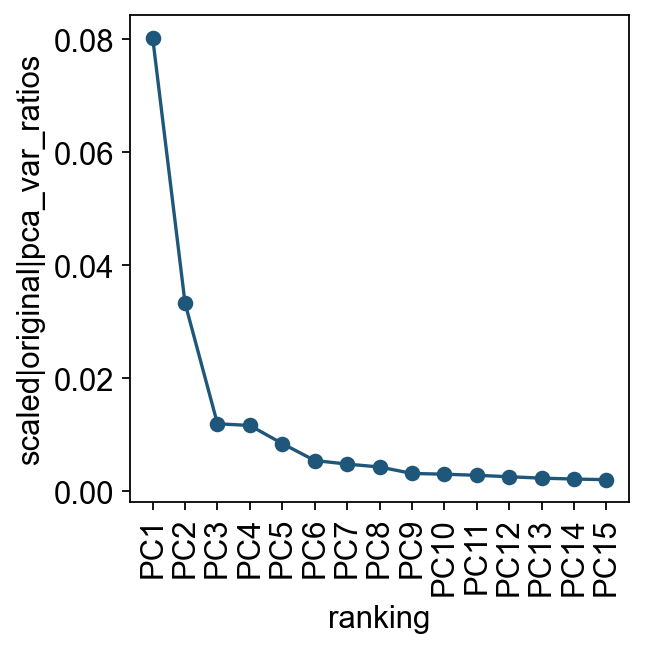

In [4]:
ov.utils.plot_pca_variance_ratio(adata, n_pcs=15)

X_umap converted to UMAP to visualize and saved to adata.obsm['UMAP']
if you want to use X_umap, please set convert=False


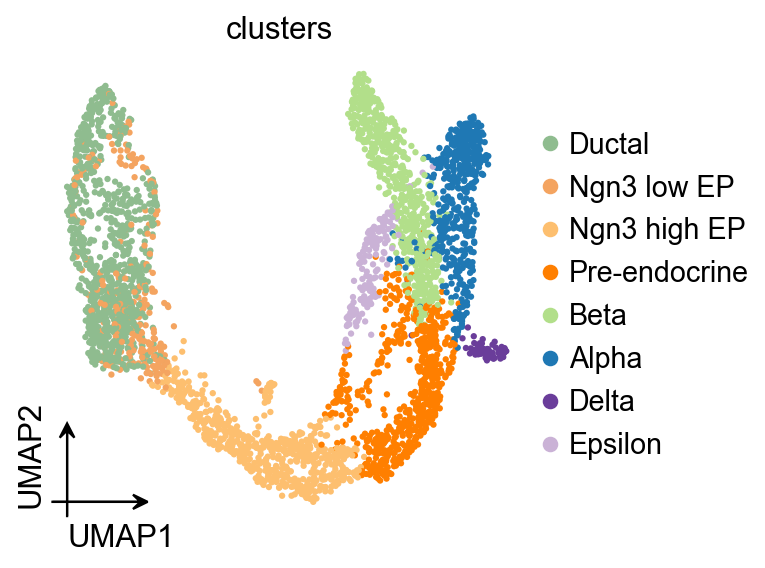

In [5]:
ov.pl.umap(
    adata,
    color='clusters'
)

## Slingshot

Slingshot infers continuous and branching lineage structures in a low-dimensional space. It was originally designed for developmental trajectory modeling in single-cell RNA-seq data, usually after dimensionality reduction and clustering. It can handle any number of branch events and can incorporate prior knowledge through semi-supervised graph construction.

In [6]:
Traj=ov.single.TrajInfer(
    adata,basis='X_umap',
    groupby='clusters',
    use_rep='scaled|original|X_pca',
    n_comps=50
)
Traj.set_origin_cells('Ductal')
#Traj.set_terminal_cells(["Granule mature","OL","Astrocytes"])

If only the inferred pseudotime ordering is needed, the `debug_axes` argument can be omitted.

In [7]:
Traj.inference(method='slingshot',num_epochs=1)

Lineages: [Lineage[3, 6, 5, 7, 1, 0], Lineage[3, 6, 5, 7, 1, 4], Lineage[3, 6, 5, 7, 2]]


  0%|          | 0/1 [00:00<?, ?it/s]

Reversing from leaf to root
Averaging branch @1 with lineages: [0, 1] [<pcurvepy2.pcurve.PrincipalCurve object at 0x15095efd0>, <pcurvepy2.pcurve.PrincipalCurve object at 0x1517f46d0>]
Averaging branch @7 with lineages: [0, 1, 2] [<pcurvepy2.pcurve.PrincipalCurve object at 0x150c8dd90>, <pcurvepy2.pcurve.PrincipalCurve object at 0x1510c62d0>]
Shrinking branch @7 with curves: [<pcurvepy2.pcurve.PrincipalCurve object at 0x150c8dd90>, <pcurvepy2.pcurve.PrincipalCurve object at 0x1510c62d0>]
Shrinking branch @1 with curves: [<pcurvepy2.pcurve.PrincipalCurve object at 0x15095efd0>, <pcurvepy2.pcurve.PrincipalCurve object at 0x1517f46d0>]


Set `debug_axes` when you want to visualize the lineage fitting process.

Lineages: [Lineage[3, 6, 5, 7, 1, 0], Lineage[3, 6, 5, 7, 1, 4], Lineage[3, 6, 5, 7, 2]]


  0%|          | 0/1 [00:00<?, ?it/s]

Reversing from leaf to root
Averaging branch @1 with lineages: [0, 1] [<pcurvepy2.pcurve.PrincipalCurve object at 0x151880510>, <pcurvepy2.pcurve.PrincipalCurve object at 0x151133ed0>]
Averaging branch @7 with lineages: [0, 1, 2] [<pcurvepy2.pcurve.PrincipalCurve object at 0x151731e50>, <pcurvepy2.pcurve.PrincipalCurve object at 0x1518bc8d0>]
Shrinking branch @7 with curves: [<pcurvepy2.pcurve.PrincipalCurve object at 0x151731e50>, <pcurvepy2.pcurve.PrincipalCurve object at 0x1518bc8d0>]
Shrinking branch @1 with curves: [<pcurvepy2.pcurve.PrincipalCurve object at 0x151880510>, <pcurvepy2.pcurve.PrincipalCurve object at 0x151133ed0>]


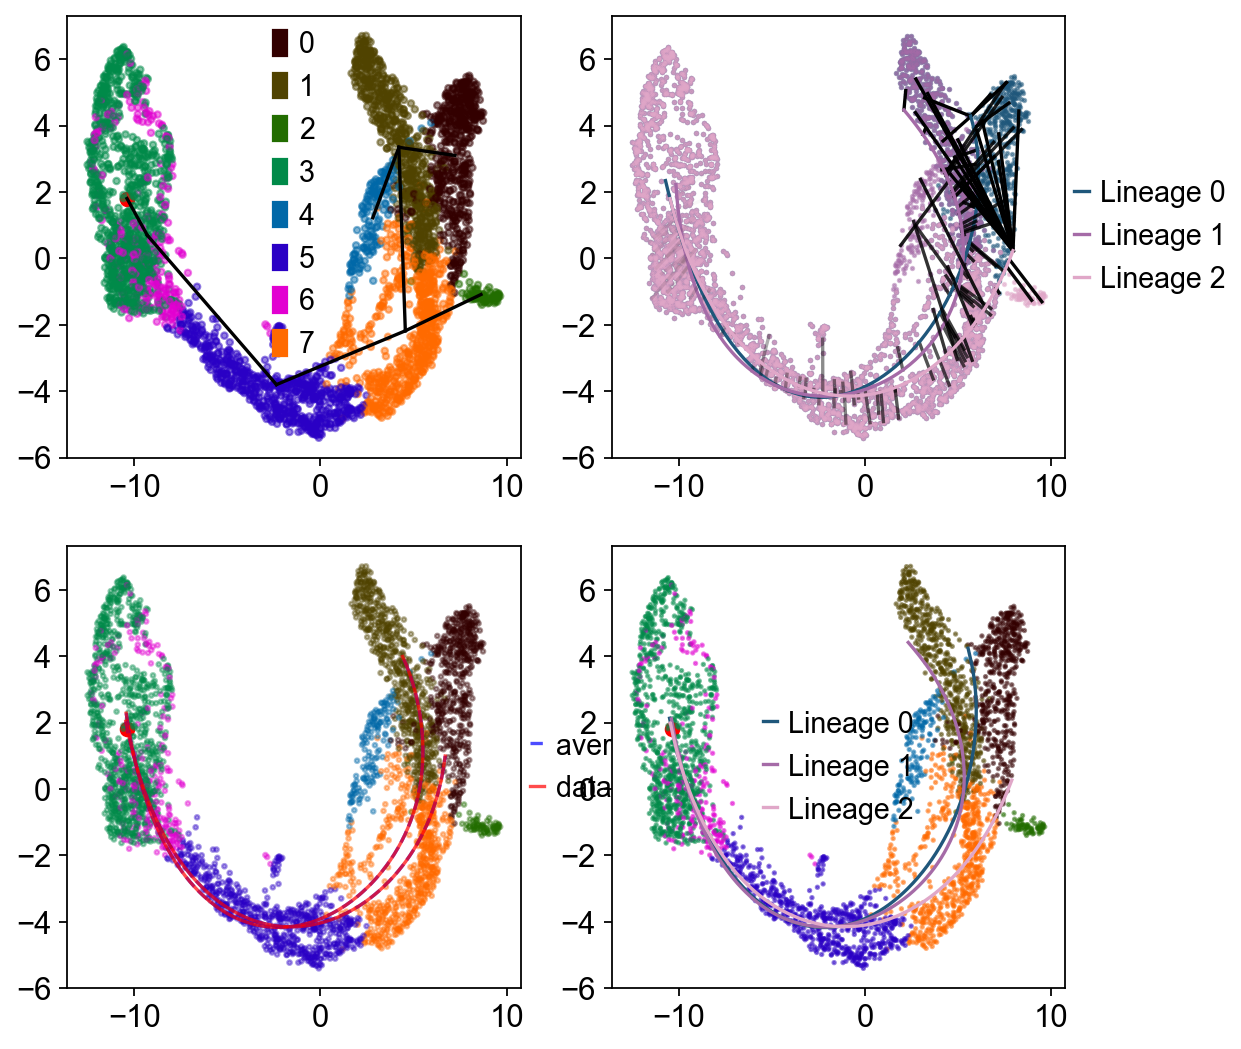

In [8]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(8, 8))
Traj.inference(method='slingshot',num_epochs=1,debug_axes=axes)

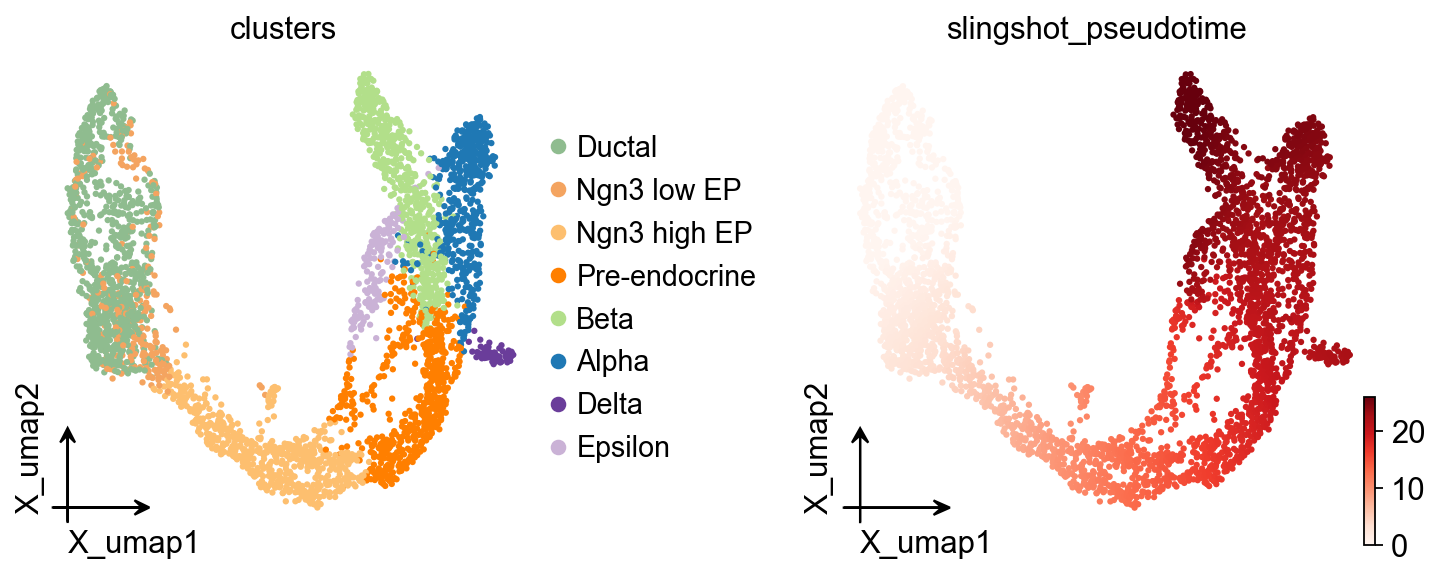

In [9]:
ov.pl.embedding(
    adata,basis='X_umap',
    color=['clusters','slingshot_pseudotime'],
    frameon='small',
    cmap='Reds'
)

## OV Slingshot curve overlay

Slingshot stores fitted lineage curves in the model object, so they can be overlaid on the unified OmicVerse embedding style.

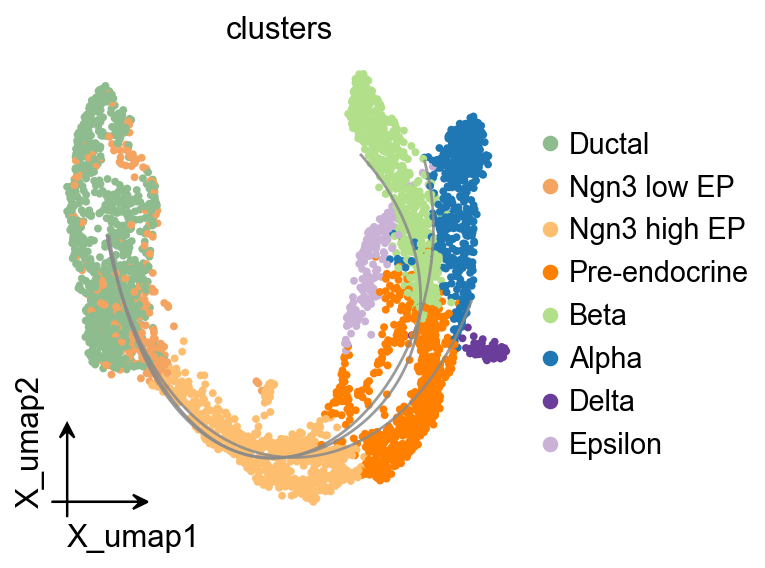

In [10]:
fig, ax = plt.subplots(figsize=(4, 4))
ov.pl.embedding(
    adata,
    basis='X_umap',
    color='clusters',
    ax=ax,
    show=False,
    size=50,
)
ov.pl.trajectory_overlay(
    adata,
    ax=ax,
    method='slingshot',
    model=Traj.slingshot,
)
plt.show()

In [11]:
sc.pp.neighbors(adata,use_rep='scaled|original|X_pca')
ov.utils.cal_paga(
    adata,
    use_time_prior='slingshot_pseudotime',
    vkey='paga',
    groups='clusters'
)

running PAGA using priors: ['slingshot_pseudotime']
    finished
added
    'paga/connectivities', connectivities adjacency (adata.uns)
    'paga/connectivities_tree', connectivities subtree (adata.uns)
    'paga/transitions_confidence', velocity transitions (adata.uns)


<Axes: title={'center': 'PAGA Slingshot-graph'}>

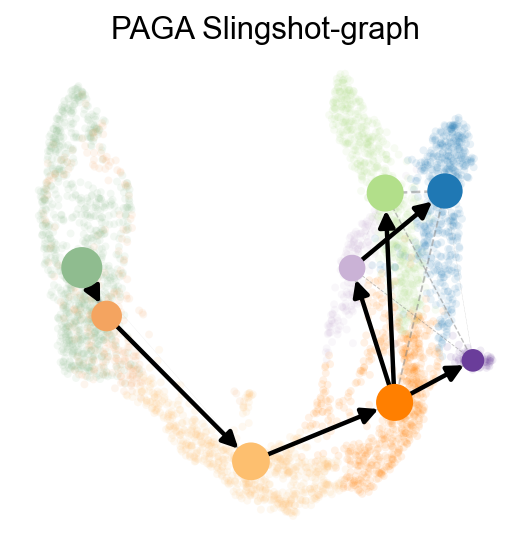

In [12]:
ov.utils.plot_paga(
    adata,basis='umap',
    size=50,
    alpha=.1,
    title='PAGA Slingshot-graph',
    min_edge_width=2,
    node_size_scale=1.5,
    show=False,
    legend_loc=False
)

### Summarize two Slingshot lineages with a mirrored dynamic heatmap

Slingshot can return multiple lineage curves. The following code converts fitted curves into cell-level lineage labels and lineage-specific pseudotime, then plots two lineages side by side. The first lineage is reversed so that the left panel points toward the branch point, which makes branch-specific programs easier to compare.

In [17]:
import pandas as pd
import numpy as np

slingshot_genes = ['Sox9', 'Neurog3', 'Fev', 'Gcg', 'Arx', 'Pax4', 'Ins2', 'Pdx1', 'Sst', 'Hhex']

n_lineages = len(Traj.slingshot.lineages)
slingshot_lineage_labels = [f'Lineage {i}' for i in range(n_lineages)]

dominant_lineage = np.asarray(Traj.slingshot.cell_weights).argmax(axis=1)
lineage_specific_pt = np.full(adata.n_obs, np.nan)

for i, curve in enumerate(Traj.slingshot.curves):
    curve_pt = np.asarray(curve.pseudotimes_interp, dtype=float)
    adata.obs[f'slingshot_lineage_{i + 1}_pt'] = curve_pt
    lineage_specific_pt[dominant_lineage == i] = curve_pt[dominant_lineage == i]

adata.obs['slingshot_lineage'] = pd.Categorical(
    [slingshot_lineage_labels[i] for i in dominant_lineage],
    categories=slingshot_lineage_labels,
    ordered=True,
)
adata.obs['slingshot_lineage_pseudotime'] = lineage_specific_pt

selected_slingshot_lineages = slingshot_lineage_labels[:2]


🔍 Dynamic heatmap:
   Candidate features: 10
   Pseudotime: slingshot_lineage_pseudotime
   Lineage key: slingshot_lineage
   Cell annotation: clusters
   use_fitted=True | cell_bins=200 | cmap=RdBu_r
   Lineages: Lineage 0, Lineage 1

✅ Dynamic heatmap completed!
   ✓ Matrix shape: 10 features × 337 columns


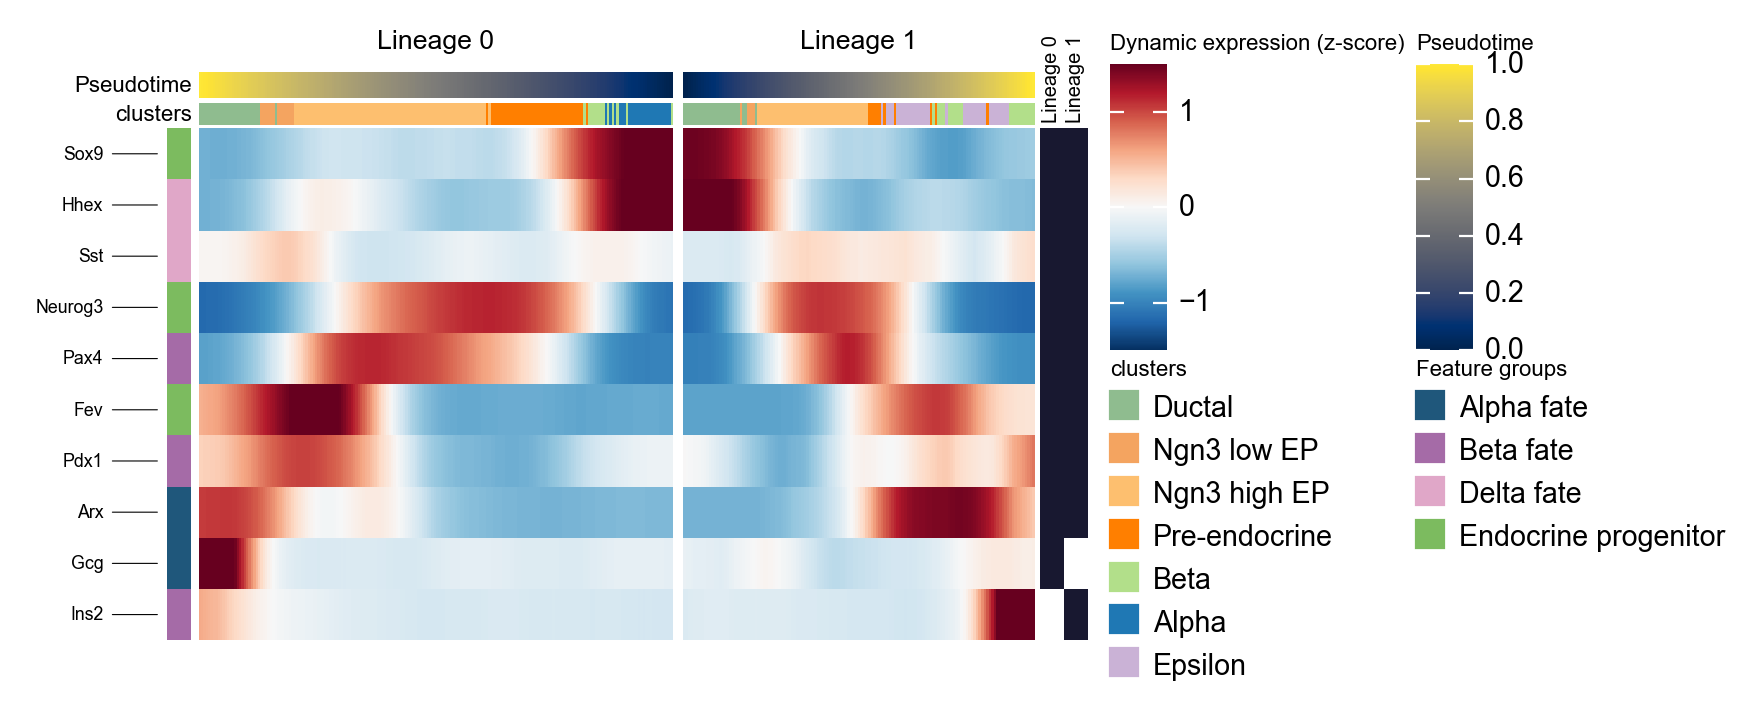

In [18]:
slingshot_marker = {
    'Alpha fate': ['Gcg', 'Arx'],
    'Beta fate': ['Pax4', 'Ins2', 'Pdx1'],
    'Delta fate': ['Sst', 'Hhex'],
    'Endocrine progenitor': ['Sox9', 'Neurog3', 'Fev'],
}

d1 = ov.pl.dynamic_heatmap(
    adata,
    var_names=slingshot_marker,
    pseudotime='slingshot_lineage_pseudotime',
    lineage_key='slingshot_lineage',
    lineages=selected_slingshot_lineages,
    reverse_ht=[selected_slingshot_lineages[0]],
    use_raw=adata.raw is not None,
    use_cell_columns=False,
    cell_annotation='clusters',
    cell_bins=200,
    smooth_window=17,
    fitted_window=31,
    figsize=(5, 4),
    standard_scale='var',
    cmap='RdBu_r',
    use_fitted=True,
    border=False,
    show=False,
)


🔍 Dynamic heatmap:
   Candidate features: 10
   Pseudotime: slingshot_lineage_pseudotime
   Lineage key: slingshot_lineage
   Cell annotation: clusters
   use_fitted=False | cell_bins=100 | cmap=viridis
   Lineages: Lineage 0, Lineage 1

✅ Dynamic heatmap completed!
   ✓ Matrix shape: 10 features × 183 columns


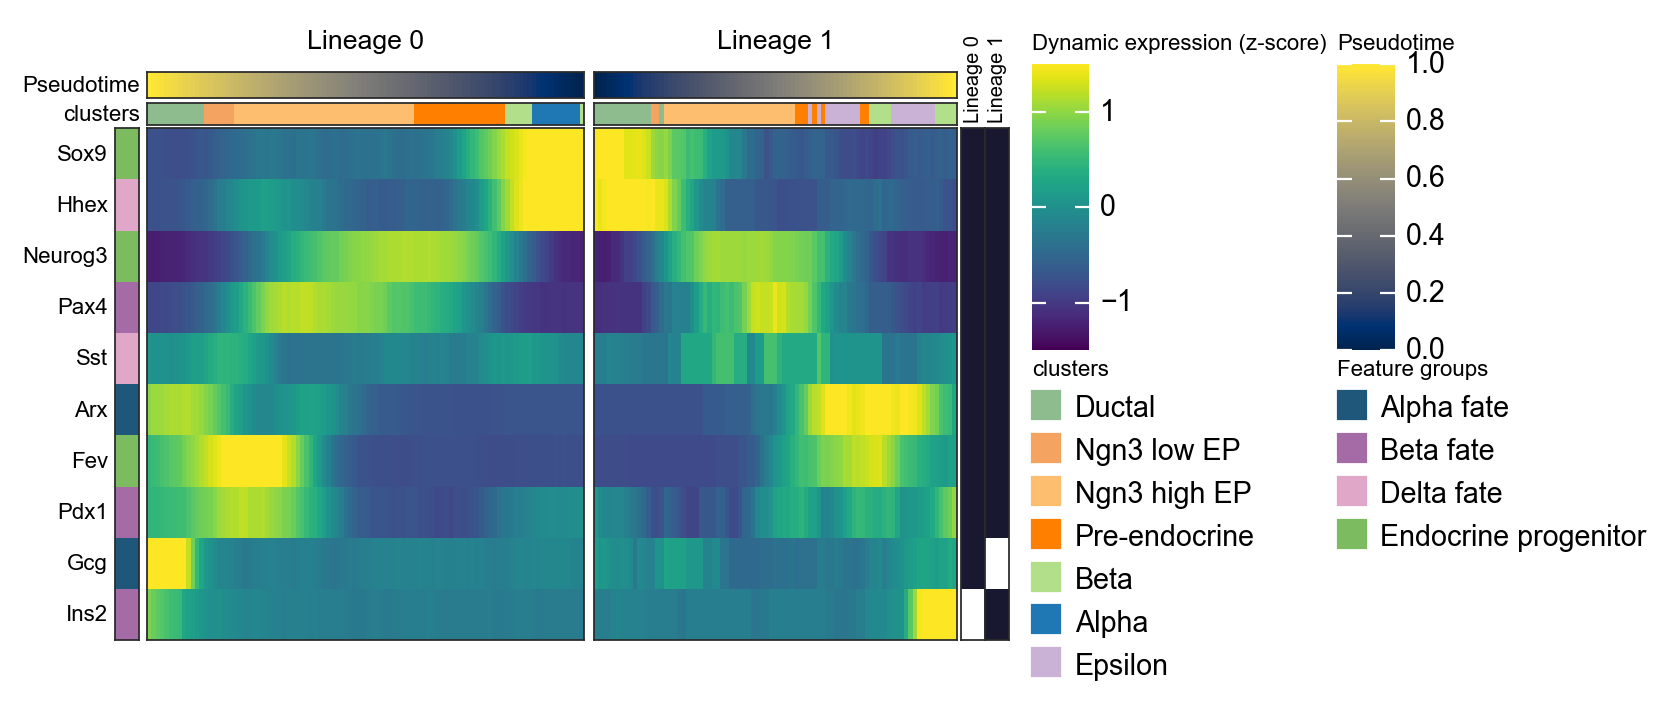

In [19]:
d1 = ov.pl.dynamic_heatmap(
    adata,
    var_names=slingshot_marker,
    pseudotime='slingshot_lineage_pseudotime',
    lineage_key='slingshot_lineage',
    lineages=selected_slingshot_lineages,
    reverse_ht=[selected_slingshot_lineages[0]],
    use_raw=adata.raw is not None,
    use_cell_columns=False,
    cell_annotation='clusters',
    figsize=(5, 4),
    standard_scale='var',
    show_row_names=True,
    use_fitted=False,
    border=True,
    show=False,
)

## Branch-aware pseudotime stream plot

`ov.pl.branch_streamplot` only needs pseudotime and cell-state labels, so it can also be used for this trajectory method. Ribbon width shows where each cell type is enriched along pseudotime, and the branch center lines help show where endocrine fates separate.

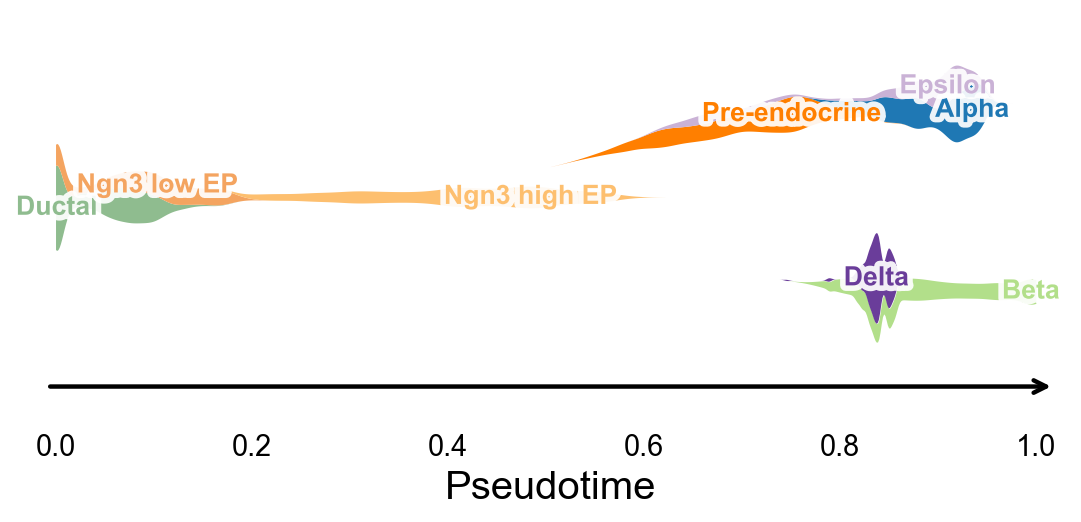

In [20]:
fig, ax = ov.pl.branch_streamplot(
    adata,
    group_key='clusters',
    pseudotime_key='slingshot_pseudotime',
    show=False,
)
plt.show()

## Embedding stream plot

### Use `dynamic_features` / `dynamic_trends` on Slingshot lineages

Here we show two complementary views. First, a global trend plot fits marker curves along `slingshot_pseudotime` with raw points colored by cluster. Second, branch trends are refitted by Slingshot lineage to compare endocrine split-associated differences.

In [22]:
slingshot_trend_genes = ['Sox9', 'Neurog3', 'Fev', 'Gcg', 'Arx', 'Pax4', 'Ins2', 'Pdx1', 'Sst', 'Hhex']

slingshot_global_dyn = ov.single.dynamic_features(
    adata,
    genes=slingshot_trend_genes,
    pseudotime='slingshot_pseudotime',
    use_raw=adata.raw is not None,
    distribution='normal',
    link='identity',
    n_splines=8,
    store_raw=True,
    raw_obs_keys=['clusters'],
)


🔍 Dynamic feature analysis:
   Views: 1 | Features: 10
   Pseudotime: slingshot_pseudotime
   Stored raw obs keys: ['clusters']
   Expression source: adata.raw
   GAM: normal-identity | splines=8


Fitting dynamic features:   0%|          | 0/10 [00:00<?, ?it/s]


✅ Dynamic feature analysis completed!
   ✓ Successful fits: 10/10
   ✓ Fitted rows: 2000
   ✓ Raw observations stored: 36960


### Single-line Global Trends

Each gene is fitted with one global trend line while raw points are colored by cell annotation. This view separates the overall pseudotime expression pattern from the cell states contributing the observations.


🔍 Dynamic trend plotting:
   Features: 4 | Groups: 1
   compare_features=False | compare_groups=False


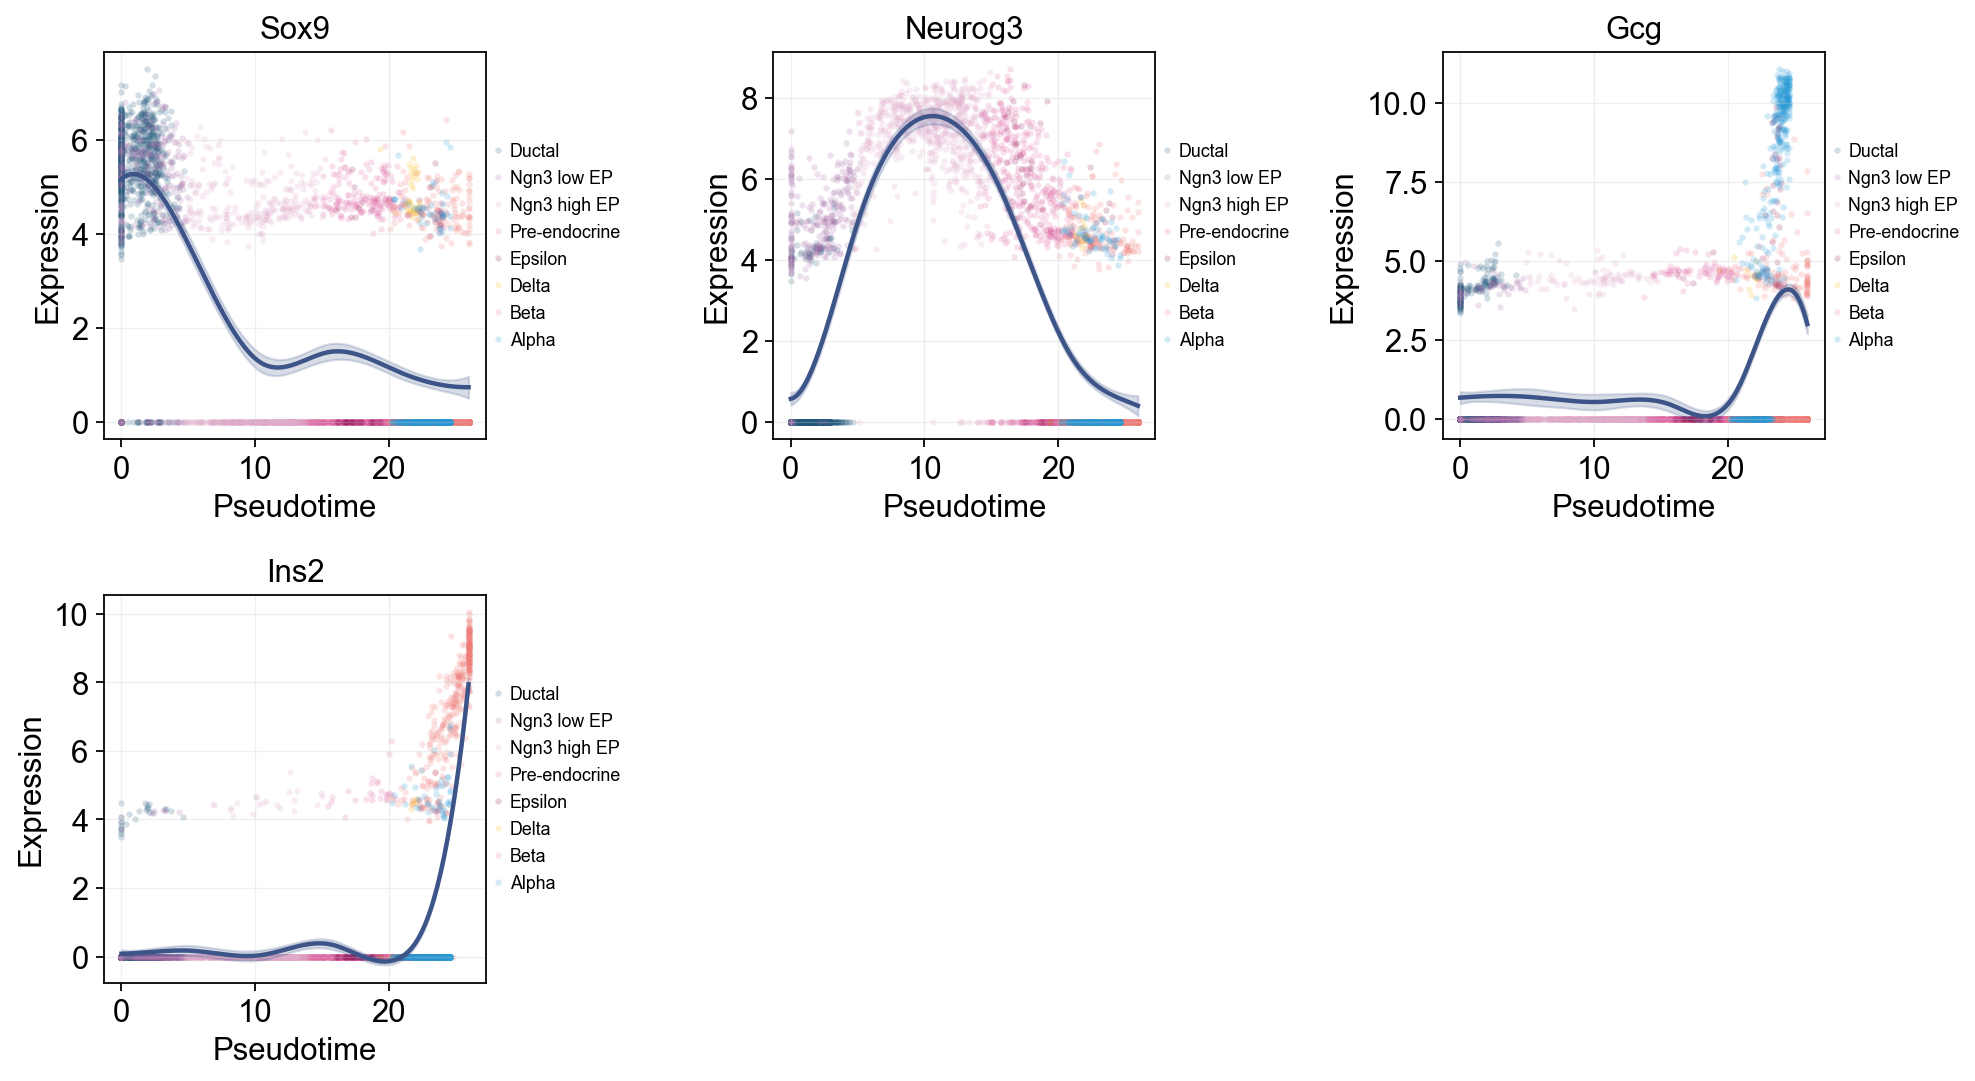

✅ Dynamic trend plotting completed!


In [23]:
ov.pl.dynamic_trends(
    slingshot_global_dyn,
    genes=['Sox9', 'Neurog3', 'Gcg', 'Ins2'],
    add_point=True,
    point_color_by='clusters',
    figsize=(5, 3.5),
    legend_loc='right margin',
    legend_fontsize=8,
)
plt.show()

### Multi-marker Trend Comparison

Multiple marker curves are overlaid on one pseudotime axis to compare activation and decay order across programs.


🔍 Dynamic trend plotting:
   Features: 4 | Groups: 1
   compare_features=True | compare_groups=False


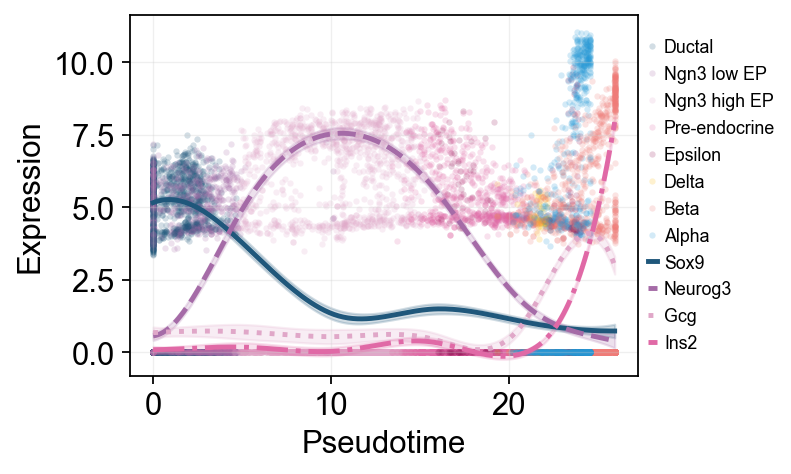

✅ Dynamic trend plotting completed!


In [24]:
ov.pl.dynamic_trends(
    slingshot_global_dyn,
    genes=['Sox9', 'Neurog3', 'Gcg', 'Ins2'],
    compare_features=True,
    add_point=True,
    point_color_by='clusters',
    line_style_by='features',
    figsize=(6.2, 3.2),
    linewidth=2.2,
    legend_loc='right margin',
    legend_fontsize=8,
)
plt.show()

In [25]:
slingshot_dyn_res = ov.single.dynamic_features(
    adata,
    genes=slingshot_trend_genes,
    pseudotime='slingshot_lineage_pseudotime',
    groupby='slingshot_lineage',
    groups=selected_slingshot_lineages,
    use_raw=adata.raw is not None,
    distribution='normal',
    link='identity',
    n_splines=8,
    store_raw=True,
)

slingshot_dyn_res.get_stats(successful_only=True).sort_values(['gene']).head(8)


🔍 Dynamic feature analysis:
   Views: 2 | Features: 10
   Pseudotime: slingshot_lineage_pseudotime
   Grouping: slingshot_lineage
   Expression source: adata.raw
   GAM: normal-identity | splines=8


Fitting dynamic features:   0%|          | 0/20 [00:00<?, ?it/s]


✅ Dynamic feature analysis completed!
   ✓ Successful fits: 20/20
   ✓ Fitted rows: 4000
   ✓ Raw observations stored: 30550


      dataset        groupby_key      group  gene  success error  n_cells  \
14  Lineage 1  slingshot_lineage  Lineage 1   Arx     True  None      533   
4   Lineage 0  slingshot_lineage  Lineage 0   Arx     True  None     2522   
2   Lineage 0  slingshot_lineage  Lineage 0   Fev     True  None     2522   
12  Lineage 1  slingshot_lineage  Lineage 1   Fev     True  None      533   
3   Lineage 0  slingshot_lineage  Lineage 0   Gcg     True  None     2522   
13  Lineage 1  slingshot_lineage  Lineage 1   Gcg     True  None      533   
9   Lineage 0  slingshot_lineage  Lineage 0  Hhex     True  None     2522   
19  Lineage 1  slingshot_lineage  Lineage 1  Hhex     True  None      533   

    exp_ncells  peak_time  valley_time  min_pseudotime  max_pseudotime  \
14         110  20.163205     8.026130             0.0       25.970730   
4          600  22.561005     7.726371             0.0       24.600767   
2         1010  19.594078     9.086213             0.0       24.600767   
12        


🔍 Dynamic trend plotting:
   Features: 4 | Groups: 2
   compare_features=False | compare_groups=True


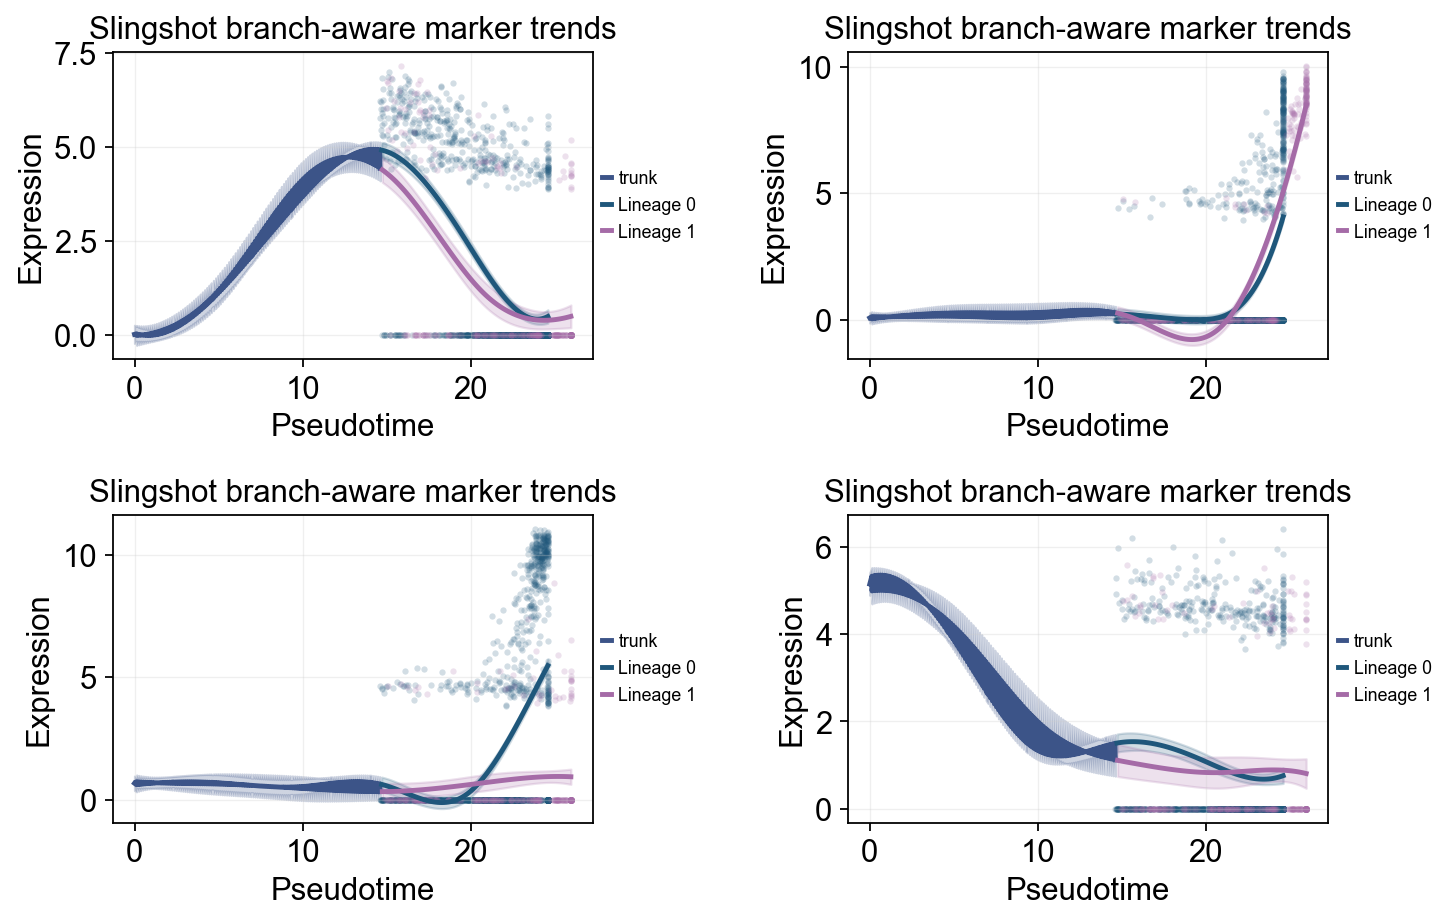

✅ Dynamic trend plotting completed!


In [26]:
slingshot_split_mask = adata.obs['clusters'].astype(str).isin(['Ngn3 high EP', 'Pre-endocrine'])
slingshot_split_time = float(np.nanmedian(adata.obs.loc[slingshot_split_mask, 'slingshot_lineage_pseudotime'])) if slingshot_split_mask.any() else float(np.nanmedian(adata.obs['slingshot_lineage_pseudotime']))

ov.pl.dynamic_trends(
    slingshot_dyn_res,
    genes=['Pax4', 'Ins2', 'Gcg', 'Sox9'],
    compare_groups=True,
    split_time=slingshot_split_time,
    shared_trunk=True,
    add_point=True,
    point_color_by='group',
    figsize=(5.5, 3),
    linewidth=2.2,
    ncols=2,
    legend_loc='right margin',
    legend_fontsize=8,
    title='Slingshot branch-aware marker trends',
)
plt.show()


🔍 Dynamic trend plotting:
   Features: 4 | Groups: 2
   compare_features=True | compare_groups=True


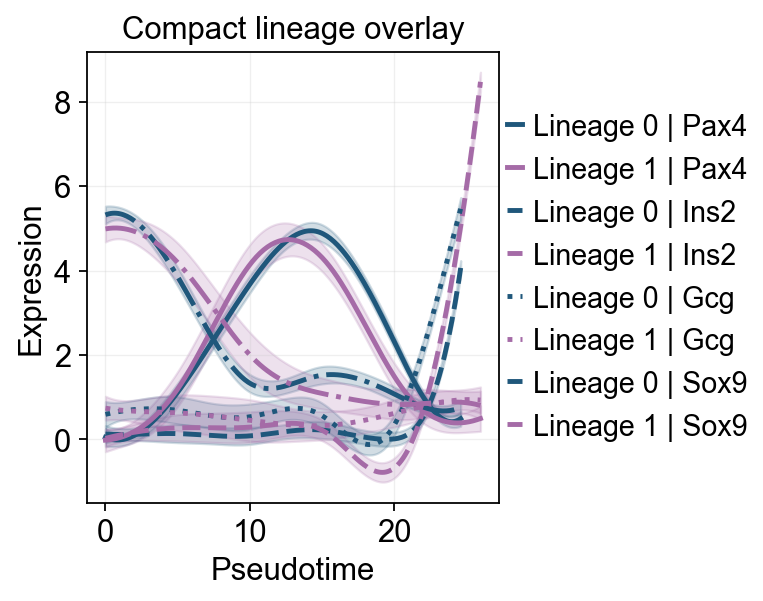

✅ Dynamic trend plotting completed!


In [27]:
ov.pl.dynamic_trends(
    slingshot_dyn_res,
    genes=['Pax4', 'Ins2', 'Gcg', 'Sox9'],
    compare_features=True,
    compare_groups=True,
    line_style_by='features',
    figsize=(6, 4),
    linewidth=2.2,
    title='Compact lineage overlay',
)
plt.show()


🔍 Dynamic heatmap:
   Candidate features: 3000
   Pseudotime: slingshot_lineage_pseudotime
   Lineage key: slingshot_lineage
   Cell annotation: clusters
   use_fitted=True | cell_bins=90 | cmap=viridis
   Lineages: Lineage 0, Lineage 1

✅ Dynamic heatmap completed!
   ✓ Matrix shape: 1000 features × 166 columns


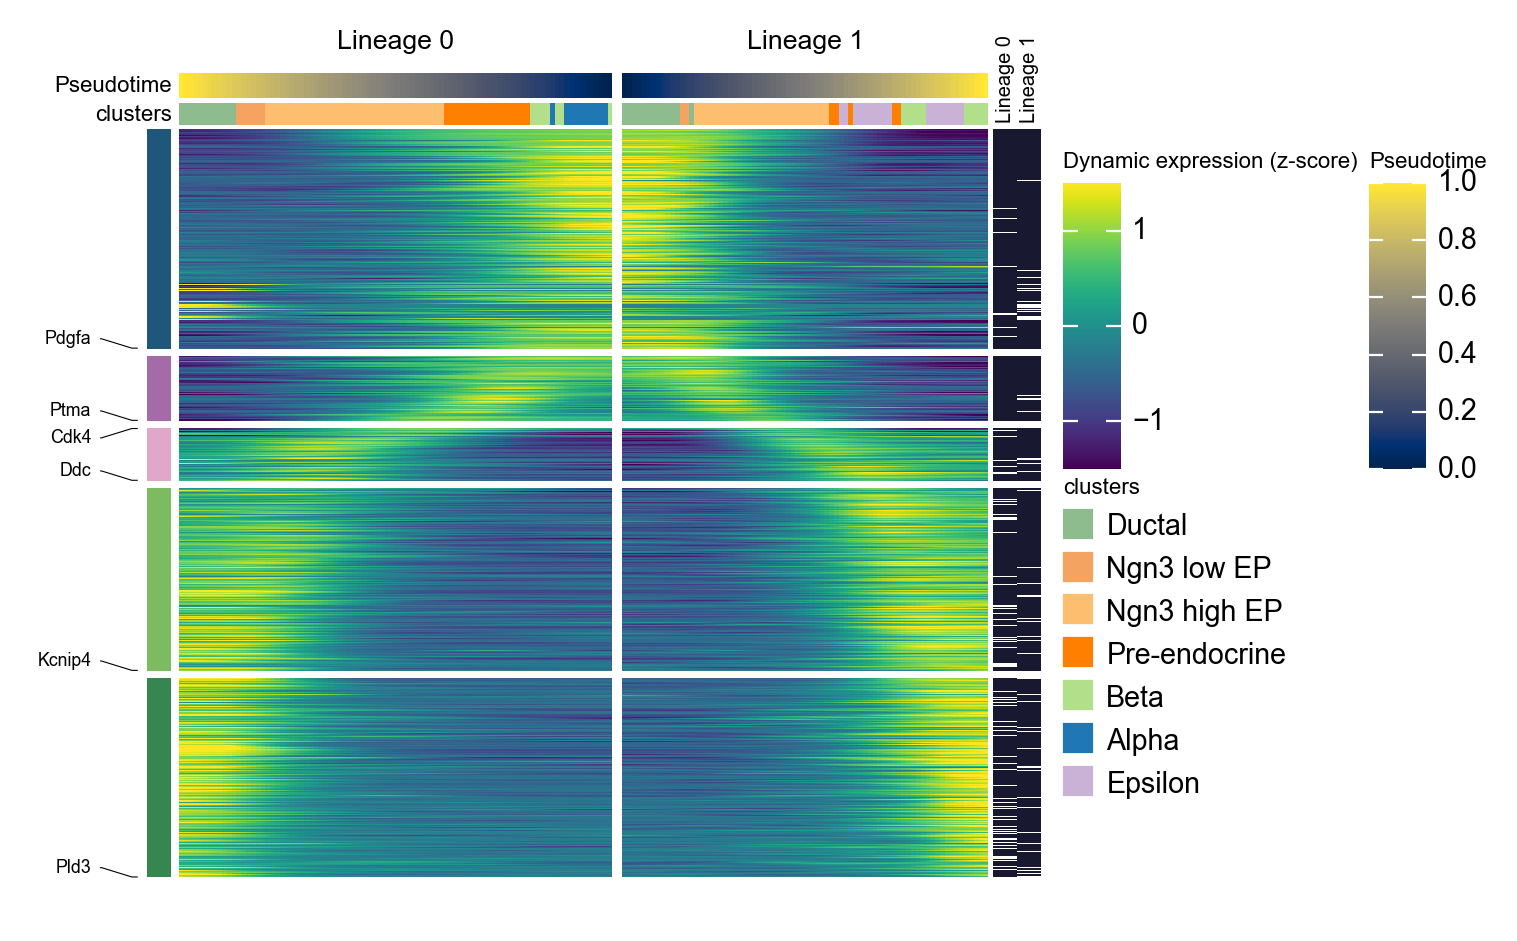

In [28]:
g = ov.pl.dynamic_heatmap(
    adata,
    top_features=1000,       # Keep the top 1000 most dynamic genes for plotting
    pseudotime='slingshot_lineage_pseudotime',
    lineage_key='slingshot_lineage',
    lineages=selected_slingshot_lineages,
    reverse_ht=[selected_slingshot_lineages[0]],
    use_raw=adata.raw is not None,
    use_cell_columns=False,
    cell_annotation='clusters',
    cell_bins=90,
    smooth_window=17,
    fitted_window=31,
    n_split=5,
    figsize=(5, 6),
    standard_scale='var',
    cmap='viridis',
    top_label_features=10,
    border=False,
    show=False,
)